# Week 37, Tuesday session: gradient descent in practice

**FYS-STK3155/4155, Tuesday September 8, 2026**

This is the notebook for the flipped session. Monday's lecture covered
cross-validation done properly (Section 3.14), convexity and Newton's method
(Sections 4.1–4.2), plain gradient descent for OLS and Ridge (Sections
4.3–4.4), the learning rate and the condition number (Section 4.5), momentum
(Section 4.6) and automatic differentiation (Section 4.14). Today you make the
code your own, in two cases:

* **Case 1** — your own gradient descent for OLS and Ridge with analytical
  gradients, on this week's exercise data: scaling, gradients, closed forms,
  the learning rate, a stopping criterion, and the eigenvalue bound
  $\gamma < 2/\lambda_{\max}$ of Eq. (4.20). This is exercises 1–4 of the week
  and part e) of Project 1.
* **Case 2** — momentum and the JAX gradient on the Runge function of
  Project 1: the gradient without deriving it, finite differences against
  automatic differentiation, momentum as one extra line, and what happens
  when $\kappa$ becomes large. Parts e) and f) of Project 1 in miniature.

The code is identical to `make_week37_figures.py`, which produced the lecture
figures, and the seed is 2026 throughout, so your numbers are the lecture's
numbers. Work in pairs; the checkpoints are discussed in plenum.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from sklearn.linear_model import Ridge

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"

## Case 1: your own gradient descent for OLS and Ridge, checked

### Step 1: the data, scaled (exercise 1)

We use this week's exercise function $f(x) = 2 - x + 5x^2$ on $[-2, 2]$ with
$n = 100$ points and Gaussian noise of standard deviation $0.5$. The design
matrix contains the powers $x, x^2, \dots, x^{d}$ — **no intercept column**.
Instead every column is standardised (mean zero, standard deviation one) and
$\boldsymbol{y}$ is centred. Section 3.13: with centred data the optimal
intercept is exactly zero, so it can be dropped, and it is then also not
penalised by Ridge — which is what we want.

The closed-form solutions are Eq. (3.44) with the factor $n$ of Eq. (3.95),
because our cost, Eq. (4.16), carries $1/n$ on the data term and not on the
penalty:

$$
\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y},
\qquad \lambda = 0 \text{ for OLS}.
$$

In [4]:
def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered

def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)


X, y = exercise_data(degree=2)
print("column means:", np.round(X.mean(axis=0), 12))
print("column stds: ", np.round(X.std(axis=0), 12))
print("mean of y:   ", np.round(y.mean(), 12))
print("closed-form OLS, degree 2:", np.round(closed_form(X, y), 4))

column means: [-0.  0.]
column stds:  [1. 1.]
mean of y:    -0.0
closed-form OLS, degree 2: [-1.0774  5.8547]


**Question for your pair:** the true function has coefficients $(-1, 5)$ on
$(x, x^2)$, but the closed form returns $(-1.08, 5.85)$. Why are these not the
same numbers, and how would you convert one to the other? (Hint: the columns
were divided by their standard deviations.)

### Step 2: the gradient and the Hessian (exercise 2)

From Eqs. (4.13) and (4.17),

$$
\nabla_{\boldsymbol{\theta}} C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}) + 2\lambda\boldsymbol{\theta},
\qquad
\boldsymbol{H} = \frac{2}{n}\boldsymbol{X}^T\boldsymbol{X} + 2\lambda\boldsymbol{I}.
$$

The gradient is the only place where the cost function enters the code.
Before using it, **check it**: a central finite difference, Eq. (4.43), of
the cost at a random $\boldsymbol{\theta}$ with $h = 10^{-5}$ should agree to
about $10^{-9}$ — not better, for the reasons of Section 4.14.1 (and Case 2).

In [5]:
def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def gradient_descent(X, y, gamma, lam=0.0, num_iters=1000, tol=1e-8, theta0=None):
    """Plain gradient descent, Eq. (4.15). Returns the iterates and the number of steps."""
    p = X.shape[1]
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    history = [theta.copy()]
    for t in range(num_iters):
        g = gradient(theta, X, y, lam)
        theta = theta - gamma * g
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t + 1

def hessian_eigs(X, lam=0.0):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


def cost(theta, X, y, lam=0.0):
    return np.sum((X @ theta - y)**2) / len(y) + lam * theta @ theta

X, y = exercise_data(degree=5)
rng = np.random.default_rng(2026)
theta = rng.standard_normal(X.shape[1])
h = 1e-5
g_fd = np.array([(cost(theta + h * e, X, y, 0.1) - cost(theta - h * e, X, y, 0.1)) / (2 * h)
                 for e in np.eye(X.shape[1])])
print("max |finite difference - analytical| =", np.max(np.abs(g_fd - gradient(theta, X, y, 0.1))))
print("Hessian eigenvalues, degree 5, OLS:  ", np.round(hessian_eigs(X), 4))
print("Hessian eigenvalues, degree 5, Ridge:", np.round(hessian_eigs(X, 0.1), 4))

max |finite difference - analytical| = 4.3606140920360303e-10
Hessian eigenvalues, degree 5, OLS:   [0.0109 0.0749 0.4085 3.8531 5.6527]
Hessian eigenvalues, degree 5, Ridge: [0.2109 0.2749 0.6085 4.0531 5.8527]


### Step 3: the closed forms, and the library convention (exercise 3)

`scikit-learn`'s `Ridge` minimises $\|\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\theta}\|^2 + \alpha\|\boldsymbol{\theta}\|^2$
without the $1/n$, so its `alpha` is our $n\lambda$ (Section 3.10). With
standardised columns and centred $\boldsymbol{y}$ we also switch its intercept
off. Before comparing two methods, compare cost functions.

In [4]:
for degree in (2, 5):
    X, y = exercise_data(degree=degree)
    n = len(y)
    for lam in (0.0, 0.01, 0.1):
        ours = closed_form(X, y, lam)
        skl = Ridge(alpha=n * lam, fit_intercept=False).fit(X, y).coef_
        print(f"degree {degree}, lambda = {lam:<5}: closed form {np.round(ours, 4)},  "
              f"max |ours - sklearn| = {np.max(np.abs(ours - skl)):.1e}")

degree 2, lambda = 0.0  : closed form [-1.0774  5.8547],  max |ours - sklearn| = 8.9e-16
degree 2, lambda = 0.01 : closed form [-1.0596  5.7947],  max |ours - sklearn| = 1.8e-15
degree 2, lambda = 0.1  : closed form [-0.9203  5.3056],  max |ours - sklearn| = 0.0e+00
degree 5, lambda = 0.0  : closed form [-1.2107  5.9442  0.1031 -0.0912  0.0479],  max |ours - sklearn| = 2.4e-14
degree 5, lambda = 0.01 : closed form [-1.1512  5.3059 -0.053   0.5199  0.1864],  max |ours - sklearn| = 1.7e-14
degree 5, lambda = 0.1  : closed form [-0.9057  3.6272 -0.1112  1.9255  0.1299],  max |ours - sklearn| = 1.8e-15


### Step 4: gradient descent with a stopping criterion (exercise 4)

The loop of Eq. (4.15), stopped when $\|\nabla C\| < 10^{-8}$ or after
`num_iters` steps. Run the four learning rates on degree 2, then on degree 5.
Watch for two things: which runs stop because the gradient is small, and which
stop because they ran out of iterations — or blew up.

In [5]:
for degree in (2, 5):
    X, y = exercise_data(degree=degree)
    theta_cf = closed_form(X, y)
    print(f"degree {degree}: closed form {np.round(theta_cf, 4)}")
    for gamma in (0.01, 0.1, 0.5, 0.8):
        with np.errstate(all="ignore"):
            hist, its = gradient_descent(X, y, gamma, num_iters=20000)
        err = np.linalg.norm(hist[-1] - theta_cf)
        status = "converged" if its < 20000 and np.isfinite(err) else ("DIVERGED" if not np.isfinite(err) or err > 1e3 else "not converged")
        print(f"   gamma = {gamma:<5}: {its:6d} iterations, |theta - closed form| = {err:9.2e}   {status}")

degree 2: closed form [-1.0774  5.8547]
   gamma = 0.01 :   1158 iterations, |theta - closed form| =  5.55e-09   converged
   gamma = 0.1  :    108 iterations, |theta - closed form| =  3.92e-09   converged
   gamma = 0.5  :     11 iterations, |theta - closed form| =  3.84e-10   converged
   gamma = 0.8  :     88 iterations, |theta - closed form| =  3.15e-09   converged
degree 5: closed form [-1.2107  5.9442  0.1031 -0.0912  0.0479]
   gamma = 0.01 :  20000 iterations, |theta - closed form| =  4.04e-02   not converged
   gamma = 0.1  :  11836 iterations, |theta - closed form| =  9.19e-07   converged
   gamma = 0.5  :  20000 iterations, |theta - closed form| =       nan   DIVERGED
   gamma = 0.8  :  20000 iterations, |theta - closed form| =       nan   DIVERGED


   gamma = 0.01 :  20000 iterations, |theta - closed form| =  4.04e-02   not converged
   gamma = 0.1  :  11836 iterations, |theta - closed form| =  9.19e-07   converged


   gamma = 0.5  :  20000 iterations, |theta - closed form| =       nan   DIVERGED
   gamma = 0.8  :  20000 iterations, |theta - closed form| =       nan   DIVERGED


**Checkpoint:** at degree 2 every learning rate converges and $\gamma = 0.5$
needs 11 iterations; at degree 5, $\gamma = 0.5$ and $0.8$ *diverge*. Nothing
about the algorithm changed — the data did. Step 5 says exactly where the
boundary sits.

### Step 5: the bound $\gamma < 2/\lambda_{\max}$, and what Ridge does to it

Section 4.5: along each eigendirection of the Hessian the error contracts by
$|1 - \gamma\lambda_i|$ per step, Eq. (4.19). Hence stability requires
$\gamma < 2/\lambda_{\max}$, Eq. (4.20), the best rate is at
$\gamma^* = 2/(\lambda_{\max} + \lambda_{\min})$, and the iteration count grows
like $\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). The following code
reproduces Monday's figure `week37_gd_convergence.pdf` — the run at
$1.02\,\gamma_{\max}$ is the black dashed line.

degree 2: lambda_max = 2.2369, lambda_min = 1.7631, kappa = 1.3, gamma_max = 0.8941, gamma* = 0.5000
degree 5: lambda_max = 5.6527, lambda_min = 0.0109, kappa = 520.3, gamma_max = 0.3538, gamma* = 0.3531


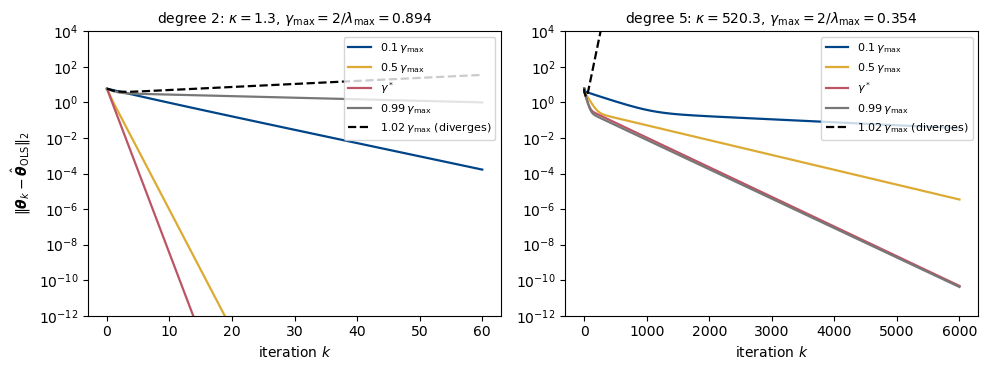

In [6]:
def fig_gd_convergence(filename="week37_gd_convergence.pdf"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for ax, degree, iters in zip(axes, (2, 5), (60, 6000)):
        X, y = exercise_data(degree=degree)
        theta_cf = closed_form(X, y)
        eigs = hessian_eigs(X)
        lmax, lmin = eigs.max(), eigs.min()
        gamma_star, gamma_max = 2.0 / (lmax + lmin), 2.0 / lmax
        gammas = [0.1 * gamma_max, 0.5 * gamma_max, gamma_star, 0.99 * gamma_max, 1.02 * gamma_max]
        labels = [r"$0.1\,\gamma_{\max}$", r"$0.5\,\gamma_{\max}$", r"$\gamma^*$",
                  r"$0.99\,\gamma_{\max}$", r"$1.02\,\gamma_{\max}$ (diverges)"]
        colors = [BLUE, YELLOW, RED, GREY, "black"]
        for gamma, lab, col in zip(gammas, labels, colors):
            hist, _ = gradient_descent(X, y, gamma, num_iters=iters, tol=0.0)
            dist = np.linalg.norm(hist - theta_cf, axis=1)
            ax.semilogy(dist, color=col, label=lab, lw=1.6,
                        ls="--" if gamma > gamma_max else "-")
        ax.set_title(rf"degree {degree}: $\kappa={lmax/lmin:.1f}$, "
                     rf"$\gamma_{{\max}}=2/\lambda_{{\max}}={gamma_max:.3f}$", fontsize=10)
        ax.set_xlabel("iteration $k$")
        ax.set_ylim(1e-12, 1e4)
        ax.legend(fontsize=8, loc="upper right")
    axes[0].set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)


for degree in (2, 5):
    X, y = exercise_data(degree=degree)
    eigs = hessian_eigs(X)
    print(f"degree {degree}: lambda_max = {eigs.max():.4f}, lambda_min = {eigs.min():.4f}, "
          f"kappa = {eigs.max()/eigs.min():.1f}, gamma_max = {2/eigs.max():.4f}, "
          f"gamma* = {2/(eigs.max()+eigs.min()):.4f}")
with np.errstate(all="ignore"):
    fig_gd_convergence("week37_gd_convergence.png")
Image("week37_gd_convergence.png")

Now the learning-rate scan of Monday's `week37_gamma_scan.pdf`: iterations to
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ against $\gamma$,
for OLS and for Ridge at two penalties. By Eq. (4.17) the Ridge Hessian is
$\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X} + 2\lambda\boldsymbol{I}$: every eigenvalue is shifted up by
$2\lambda$, which matters a great deal for $\lambda_{\min}$ and hardly at all
for $\lambda_{\max}$. The condition number drops, $\gamma_{\max}$ barely moves,
and the iteration count at the optimum falls accordingly. (This cell takes a
few seconds.)

lambda = 0.0  : kappa =   520.3, gamma_max = 0.3538, iterations at gamma* = 3410
lambda = 0.01 : kappa =   183.8, gamma_max = 0.3526, iterations at gamma* = 1177
lambda = 0.1  : kappa =    27.8, gamma_max = 0.3417, iterations at gamma* = 177


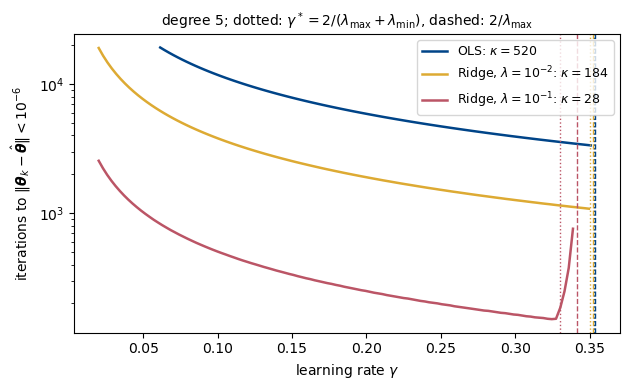

In [7]:
def iterations_to_accuracy(X, y, gamma, lam=0.0, acc=1e-6, max_iters=20000):
    theta_cf = closed_form(X, y, lam)
    theta = np.zeros(X.shape[1])
    for t in range(1, max_iters + 1):
        theta = theta - gamma * gradient(theta, X, y, lam)
        err = np.linalg.norm(theta - theta_cf)
        if err < acc:
            return t
        if not np.isfinite(err) or err > 1e6:
            return np.nan
    return np.nan

def fig_gamma_scan(filename="week37_gamma_scan.pdf"):
    X, y = exercise_data(degree=5)
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for lam, col, lab in ((0.0, BLUE, "OLS"), (0.01, YELLOW, r"Ridge, $\lambda=10^{-2}$"),
                          (0.1, RED, r"Ridge, $\lambda=10^{-1}$")):
        eigs = hessian_eigs(X, lam)
        lmax, lmin = eigs.max(), eigs.min()
        gammas = np.linspace(0.02, 2.0 / lmax * 1.05, 120)
        its = [iterations_to_accuracy(X, y, gamma, lam) for gamma in gammas]
        ax.semilogy(gammas, its, color=col, lw=1.8,
                    label=rf"{lab}: $\kappa={lmax/lmin:.0f}$")
        ax.axvline(2.0 / (lmax + lmin), color=col, ls=":", lw=1)
        ax.axvline(2.0 / lmax, color=col, ls="--", lw=1)
    ax.set_xlabel(r"learning rate $\gamma$")
    ax.set_ylabel(r"iterations to $\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}\|<10^{-6}$")
    ax.set_title(r"degree 5; dotted: $\gamma^*=2/(\lambda_{\max}+\lambda_{\min})$, "
                 r"dashed: $2/\lambda_{\max}$", fontsize=10)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)


X, y = exercise_data(degree=5)
for lam in (0.0, 0.01, 0.1):
    eigs = hessian_eigs(X, lam)
    print(f"lambda = {lam:<5}: kappa = {eigs.max()/eigs.min():7.1f}, gamma_max = {2/eigs.max():.4f}, "
          f"iterations at gamma* = {iterations_to_accuracy(X, y, 2/(eigs.max()+eigs.min()), lam)}")
with np.errstate(all="ignore"):
    fig_gamma_scan("week37_gamma_scan.png")
Image("week37_gamma_scan.png")

**Checkpoints for Case 1** (plenary): degree 2 has $\kappa = 1.3$ and
converges in 11 iterations at $\gamma^* = 0.5$; degree 5 has $\kappa = 520$,
$\gamma_{\max} = 0.354$, and needs 4964 iterations at $\gamma^*$ and 11 836 at
$\gamma = 0.1$; Ridge with $\lambda = 0.1$ brings $\kappa$ down to 28. Two
sentences to take home: *the safe learning rate is a property of the data, not
of the algorithm — compute $\lambda_{\max}$*; and *regularisation makes the
optimisation easier as well as the estimator better behaved*.

### Case 1: do you have the insight? (discussed in plenum)

1. Your loop stopped after its 1000 allowed iterations with
   $\|\nabla C\| = 10^{-4}$, small but not below tolerance. Has it converged?
   What single number tells you how far off you may still be?
2. Standardising the columns changed the iteration count by two orders of
   magnitude but not the fitted curve. Why does gradient descent care about
   the scaling when the closed form does not?
3. Ridge with $\lambda = 0.1$ converged in a twentieth of the iterations OLS
   needed. Is the point it converged to a better solution of the OLS problem?
4. The same code diverged at $\gamma = 0.5$ on degree 5 and converged at
   $\gamma = 0.8$ on degree 2. Where does the boundary come from, and what
   should the code compute before it starts?

1. $\|\nabla C\| = 10^{-4}$ is exremenly low which either means we're converging or that the number is just extremely low, and has nothing to do with being close to the minimum. We can get some insight on which one it is, we would take the maximum igen value divided by the mimum igen value. If the number is extremely large, then we'll need more iterations to get the result.
   Condition number would be very low if the matrix is close to not being invertible, so if the condition number is near zero, it's close to not being invertible.
2. If you normalize the columns, the igen values will be closer to each other. When you do OLS, you don't need to worry about scaling, but when you do gradient descuent, you do want to worry  about scaling, because it'll gt you a better condition number.
3. 

## Case 2: momentum and the automatic gradient on the Runge function

Parts e) and f) of Project 1 use the Runge function $f(x) = 1/(1 + 25x^2)$ on
$[-1, 1]$. We take $n = 100$ points, noise $\sigma = 0.1$, and a degree-6
polynomial with standardised columns — a problem with $\kappa \approx 1800$,
where plain gradient descent is genuinely slow.

### Step 1: the gradient without deriving it

Section 4.14.7: write the cost as an ordinary function of $\boldsymbol{\theta}$,
hand it to `jax.grad`, and compare with the analytical gradient of Case 1.
The first line, `jax_enable_x64`, is not optional — without it JAX works in
single precision and the comparison stops at $10^{-6}$, which would wrongly
suggest that automatic differentiation is inexact.

In [8]:
def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()


import jax
jax.config.update("jax_enable_x64", True)     # double precision throughout
import jax.numpy as jnp
from jax import grad, jit

def cost_jax(theta, X, y):                     # Eq. (4.12), ordinary code
    return jnp.sum((X @ theta - y)**2) / len(y)

def ridge_cost_jax(theta, X, y, lam):          # Eq. (4.16)
    return jnp.sum((X @ theta - y)**2) / len(y) + lam * jnp.sum(theta**2)

X, y = runge_data()
Xj, yj = jnp.asarray(X), jnp.asarray(y)
theta = np.random.default_rng(2026).standard_normal(X.shape[1])

g_ad = np.asarray(grad(cost_jax)(jnp.asarray(theta), Xj, yj))
print("OLS:   max |AD - analytical| =", np.max(np.abs(g_ad - gradient(theta, X, y))))
g_ad = np.asarray(grad(ridge_cost_jax)(jnp.asarray(theta), Xj, yj, 0.1))
print("Ridge: max |AD - analytical| =", np.max(np.abs(g_ad - gradient(theta, X, y, 0.1))))

# the derivative with respect to lambda, argument number 3: theta^T theta by Eq. (4.16)
print("dC/dlambda =", float(grad(ridge_cost_jax, argnums=3)(jnp.asarray(theta), Xj, yj, 0.1)),
      " theta^T theta =", theta @ theta)

# what single precision would have given
g32 = grad(ridge_cost_jax)(jnp.asarray(theta, dtype=jnp.float32), jnp.asarray(X, dtype=jnp.float32),
                           jnp.asarray(y, dtype=jnp.float32), jnp.float32(0.1))
print("Ridge in float32: max |AD - analytical| =", np.max(np.abs(np.asarray(g32) - gradient(theta, X, y, 0.1))))

OLS:   max |AD - analytical| = 4.440892098500626e-16
Ridge: max |AD - analytical| = 8.881784197001252e-16
dC/dlambda = 6.723862003906882  theta^T theta = 6.723862003906883
Ridge in float32: max |AD - analytical| = 5.169319434727981e-07


Ridge: max |AD - analytical| = 8.881784197001252e-16


dC/dlambda = 6.723862003906883  theta^T theta = 6.723862003906883


Ridge in float32: max |AD - analytical| = 5.169319439168873e-07


### Step 2: finite differences against automatic differentiation

Panel (a) is the scalar function of book Section 4.14.9, $f(x) = \sin(2\pi x + x^2)$
at $x = 1$: the central-difference error falls as $h^2$ (Eq. 4.44) until
$h \approx \epsilon_M^{1/3} \approx 10^{-6}$ and then rises as $\epsilon_M/h$
(Eq. 4.45), the best value being about $10^{-11}$, Eq. (4.46). Panel (b) is
the OLS gradient of the degree-5 exercise data, one central difference per
component. **Look at the right-hand side of panel (b) before reading on:**
why is there no rising $h^2$ branch?

(a) JAX error 0.0e+00; best central difference 1.2e-11 at h = 6e-07
(b) JAX error 1.8e-15; best central difference 4.6e-14 at h = 6e-02


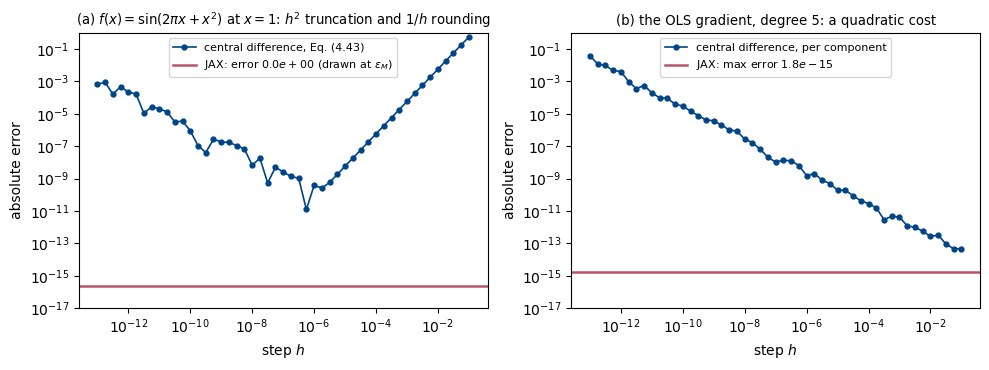

In [9]:
def fig_ad_check(filename="week37_ad_check.pdf"):
    import jax
    jax.config.update("jax_enable_x64", True)
    import jax.numpy as jnp
    from jax import grad

    # (a) the scalar function of book Section 4.14.9, whose third derivative is not zero
    def f(x):
        return jnp.sin(2 * jnp.pi * x + x**2)
    exact = (2 * np.pi + 2) * np.cos(2 * np.pi + 1)
    hs = np.logspace(-13, -1, 49)
    fd_scalar = [abs(float((f(1.0 + h) - f(1.0 - h)) / (2 * h)) - exact) for h in hs]
    ad_scalar = abs(float(grad(f)(1.0)) - exact)

    # (b) the OLS gradient of the degree-5 exercise data: a quadratic cost
    X, y = exercise_data(degree=5)
    Xj, yj = jnp.asarray(X), jnp.asarray(y)

    def cost(theta, X, y):                       # Eq. (4.12), ordinary code
        return jnp.sum((X @ theta - y)**2) / len(y)

    theta = np.asarray(np.random.default_rng(2026).standard_normal(X.shape[1]))
    g_hand = gradient(theta, X, y)               # Eq. (4.13)
    g_ad = np.asarray(grad(cost)(jnp.asarray(theta), Xj, yj))
    ad_err = np.max(np.abs(g_ad - g_hand))
    fd_err = []
    for h in hs:
        g_fd = np.zeros_like(theta)
        for j in range(len(theta)):              # one central difference per component, Eq. (4.43)
            e = np.zeros_like(theta); e[j] = h
            g_fd[j] = (float(cost(jnp.asarray(theta + e), Xj, yj))
                       - float(cost(jnp.asarray(theta - e), Xj, yj))) / (2 * h)
        fd_err.append(np.max(np.abs(g_fd - g_hand)))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].loglog(hs, fd_scalar, "o-", color=BLUE, ms=3.5, lw=1.2, label="central difference, Eq. (4.43)")
    axes[0].axhline(max(ad_scalar, 2.2e-16), color=RED, lw=1.8,
                    label=rf"JAX: error ${ad_scalar:.1e}$ (drawn at $\epsilon_M$)")
    axes[0].set_title(r"(a) $f(x)=\sin(2\pi x+x^2)$ at $x=1$: $h^2$ truncation and $1/h$ rounding", fontsize=9.5)
    axes[1].loglog(hs, fd_err, "o-", color=BLUE, ms=3.5, lw=1.2, label="central difference, per component")
    axes[1].axhline(max(ad_err, 1e-17), color=RED, lw=1.8, label=rf"JAX: max error ${ad_err:.1e}$")
    axes[1].set_title("(b) the OLS gradient, degree 5: a quadratic cost", fontsize=9.5)
    for ax in axes:
        ax.set_xlabel("step $h$")
        ax.set_ylabel("absolute error")
        ax.set_ylim(1e-17, 1e0)
        ax.legend(fontsize=8, loc="upper center")
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)
    return ad_err, ad_scalar, hs, np.array(fd_scalar), np.array(fd_err)


ad_err, ad_scalar, hs, fd_scalar, fd_err = fig_ad_check("week37_ad_check.png")
print(f"(a) JAX error {ad_scalar:.1e}; best central difference {fd_scalar.min():.1e} at h = {hs[np.argmin(fd_scalar)]:.0e}")
print(f"(b) JAX error {ad_err:.1e}; best central difference {fd_err.min():.1e} at h = {hs[np.argmin(fd_err)]:.0e}")
Image("week37_ad_check.png")

**Answer:** the OLS cost is a quadratic, so $f''' \equiv 0$ and the truncation
term of Eq. (4.45) vanishes identically — a central difference of a quadratic
is exact for any $h$, and only the $1/h$ rounding error is left. This is why
your check in Case 1 with $h = 10^{-5}$ gave $10^{-9}$ rather than $10^{-15}$:
rounding, $\epsilon_M |C| / h$. The moment the cost stops being quadratic
(logistic regression next week, neural networks later), panel (a) is the
general case, and the JAX derivative is the only one that sits at the
rounding floor for every $h$.

### Step 3: momentum — one line more than gradient descent

Eq. (4.23): $\boldsymbol{v}_{k+1} = \beta\boldsymbol{v}_k + \gamma\nabla C(\boldsymbol{\theta}_k)$,
$\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1}$. In the flat
directions successive gradients add up and the effective step becomes
$\gamma/(1-\beta)$, Eq. (4.25); in the steep direction they alternate in sign
and cancel. The contraction rate improves from $(\kappa-1)/(\kappa+1)$ to
$(\sqrt\kappa - 1)/(\sqrt\kappa + 1)$, Eq. (4.26), with tuned parameters. Here
we keep $\gamma = 0.9 \cdot 2/\lambda_{\max}$ fixed and vary only $\beta$.

Runge, degree 6: lambda_max = 5.995, lambda_min = 3.24e-03, kappa = 1849
   beta = 0.0: first iteration with |theta - closed form| < 1e-6: 15374
   beta = 0.5: first iteration with |theta - closed form| < 1e-6: 7669
   beta = 0.9: first iteration with |theta - closed form| < 1e-6: 1391


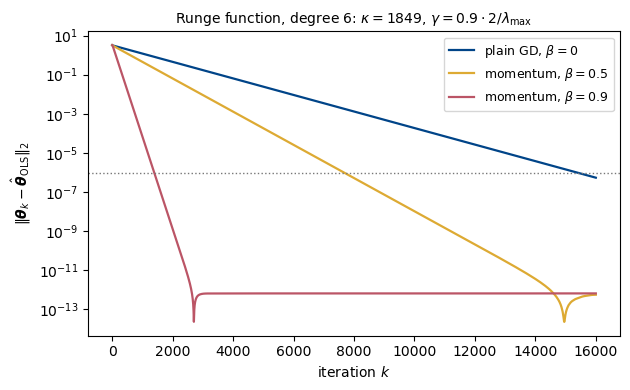

   beta = 0.5: first iteration with |theta - closed form| < 1e-6: 7669


   beta = 0.9: first iteration with |theta - closed form| < 1e-6: 1391


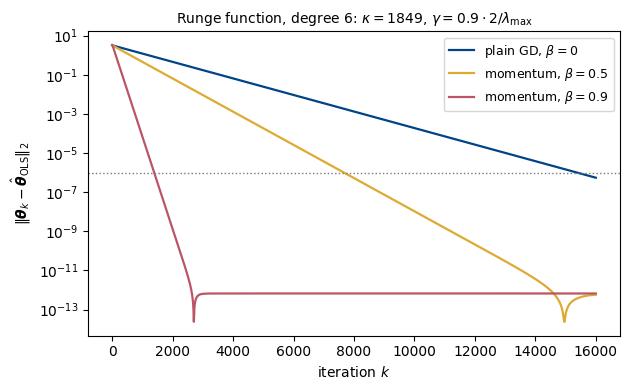

In [10]:
def momentum_descent(X, y, gamma, beta, lam=0.0, num_iters=5000, tol=1e-8):
    """Gradient descent with momentum, Eq. (4.23). beta = 0 is plain gradient descent."""
    theta, v = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    history = [theta.copy()]
    for t in range(num_iters):
        g = gradient(theta, X, y, lam)
        v = beta * v + gamma * g
        theta = theta - v
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t + 1

def fig_momentum(filename="week37_momentum.pdf"):
    X, y = runge_data()
    theta_cf = closed_form(X, y)
    eigs = hessian_eigs(X)
    lmax, lmin = eigs.max(), eigs.min()
    gamma = 0.9 * 2.0 / lmax
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for beta, col, lab in ((0.0, BLUE, r"plain GD, $\beta=0$"),
                            (0.5, YELLOW, r"momentum, $\beta=0.5$"),
                            (0.9, RED, r"momentum, $\beta=0.9$")):
        hist, _ = momentum_descent(X, y, gamma, beta, num_iters=16000, tol=0.0)
        ax.semilogy(np.linalg.norm(hist - theta_cf, axis=1), color=col, lw=1.6, label=lab)
    ax.axhline(1e-6, color=GREY, ls=":", lw=1)
    ax.set_xlabel("iteration $k$")
    ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    ax.set_title(rf"Runge function, degree 6: $\kappa={lmax/lmin:.0f}$, "
                 rf"$\gamma=0.9\cdot2/\lambda_{{\max}}$", fontsize=10)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)


X, y = runge_data()
eigs = hessian_eigs(X)
lmax, lmin = eigs.max(), eigs.min()
print(f"Runge, degree 6: lambda_max = {lmax:.3f}, lambda_min = {lmin:.2e}, kappa = {lmax/lmin:.0f}")
gamma = 0.9 * 2.0 / lmax
theta_cf = closed_form(X, y)
for beta in (0.0, 0.5, 0.9):
    hist, _ = momentum_descent(X, y, gamma, beta, num_iters=20000, tol=0.0)
    dist = np.linalg.norm(hist - theta_cf, axis=1)
    first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
    print(f"   beta = {beta}: first iteration with |theta - closed form| < 1e-6: {first}")
fig_momentum("week37_momentum.png")
Image("week37_momentum.png")

**Checkpoint:** $15\,374$, $7\,669$ and $1\,391$ iterations — a factor 11 from
$\beta = 0.9$, against the ceiling $\sqrt{1849} = 43$ of Eq. (4.26) that
would need $\gamma$ and $\beta$ tuned together. The optimal momentum for this
$\kappa$ is $\beta^* = \big((\sqrt\kappa - 1)/(\sqrt\kappa + 1)\big)^2 = 0.91$;
try it, and try $0.99$ — Monday's "Pause and think 6".

### Step 4: sensitivity to the learning rate

Momentum changes the stability condition: the two-term recurrence along an
eigendirection converges for $\gamma\lambda_{\max} < 2(1 + \beta)$. Repeat step 3
at a quarter of $\gamma_{\max}$ and at $1.5\,\gamma_{\max}$, where plain gradient
descent must diverge.

In [11]:
for factor, label in ((0.25, "gamma_max/4"), (1.5, "1.5 gamma_max")):
    eta_ = factor * 2.0 / lmax
    print(f"{label} = {eta_:.4f}:")
    for beta in (0.0, 0.5, 0.9):
        with np.errstate(all="ignore"):
            hist, _ = momentum_descent(X, y, eta_, beta, num_iters=30000, tol=0.0)
        dist = np.linalg.norm(hist - theta_cf, axis=1)
        first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
        final = dist[-1] if np.isfinite(dist[-1]) else np.inf
        print(f"   beta = {beta}: final error {final:9.2e}, first < 1e-6 at iteration {first}, "
              f"gamma*lambda_max = {eta_*lmax:.2f} vs 2(1+beta) = {2*(1+beta):.1f}")

gamma_max/4 = 0.0834:
   beta = 0.0: final error  9.52e-04, first < 1e-6 at iteration None, gamma*lambda_max = 0.50 vs 2(1+beta) = 2.0
   beta = 0.5: final error  2.83e-07, first < 1e-6 at iteration 27665, gamma*lambda_max = 0.50 vs 2(1+beta) = 3.0
   beta = 0.9: final error  6.06e-13, first < 1e-6 at iteration 5401, gamma*lambda_max = 0.50 vs 2(1+beta) = 3.8
1.5 gamma_max = 0.5004:


/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/numpy/linalg/linalg.py:2546: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/numpy/linalg/linalg.py:2547: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


   beta = 0.0: final error       inf, first < 1e-6 at iteration None, gamma*lambda_max = 3.00 vs 2(1+beta) = 2.0
   beta = 0.5: final error  2.81e-01, first < 1e-6 at iteration None, gamma*lambda_max = 3.00 vs 2(1+beta) = 3.0
   beta = 0.9: final error  6.61e-13, first < 1e-6 at iteration 761, gamma*lambda_max = 3.00 vs 2(1+beta) = 3.8


   beta = 0.9: final error  5.97e-13, first < 1e-6 at iteration 5401, gamma*lambda_max = 0.50 vs 2(1+beta) = 3.8
1.5 gamma_max = 0.5004:


/usr/local/lib/python3.10/dist-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/usr/local/lib/python3.10/dist-packages/numpy/linalg/_linalg.py:2781: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


   beta = 0.0: final error       inf, first < 1e-6 at iteration None, gamma*lambda_max = 3.00 vs 2(1+beta) = 2.0


   beta = 0.5: final error  2.81e-01, first < 1e-6 at iteration None, gamma*lambda_max = 3.00 vs 2(1+beta) = 3.0


   beta = 0.9: final error  6.60e-13, first < 1e-6 at iteration 761, gamma*lambda_max = 3.00 vs 2(1+beta) = 3.8


**Checkpoint:** at $1.5\,\gamma_{\max}$ plain gradient descent diverges
($\gamma\lambda_{\max} = 3 > 2$); $\beta = 0.5$ sits exactly on its own edge
$2(1+\beta) = 3$ and oscillates for ever; $\beta = 0.9$ converges, in 761
iterations — *faster* than at $0.9\,\gamma_{\max}$. Momentum does not only speed
up the flat directions, it also widens the window of usable learning rates.
At $\gamma_{\max}/4$ everything is simply four times slower.

### Step 5: swap the gradient, then raise the degree

The update rule does not care where the gradient comes from. Below,
`momentum_descent_with` takes the gradient *function* as an argument, and we
pass the compiled JAX gradient of `cost_jax`. Then degree 10: what is $\kappa$,
and does anything converge?

In [12]:
def momentum_descent_with(grad_fn, p, gamma, beta, num_iters=5000, tol=1e-8):
    """Eq. (4.23) with any gradient function grad_fn(theta)."""
    theta, v = np.zeros(p), np.zeros(p)
    history = [theta.copy()]
    for t in range(num_iters):
        g = np.asarray(grad_fn(theta))
        v = beta * v + gamma * g
        theta = theta - v
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t + 1

# degree 6 with the JAX gradient: identical iterates to the analytical run
grad_jax = jit(grad(cost_jax))
hist_ad, its_ad = momentum_descent_with(lambda th: grad_jax(jnp.asarray(th), Xj, yj), X.shape[1], gamma, 0.9, num_iters=20000)
hist_an, its_an = momentum_descent(X, y, gamma, 0.9, num_iters=20000)
print(f"degree 6, beta = 0.9: analytical gradient {its_an} iterations, JAX gradient {its_ad} iterations, "
      f"max difference between the two final theta: {np.max(np.abs(hist_ad[-1] - hist_an[-1])):.1e}")

# degree 10: the condition number explodes
X10, y10 = runge_data(degree=10)
theta10 = closed_form(X10, y10)
eigs10 = hessian_eigs(X10)
print(f"degree 10: lambda_max = {eigs10.max():.2f}, lambda_min = {eigs10.min():.2e}, kappa = {eigs10.max()/eigs10.min():.2e}")
gamma10 = 0.9 * 2.0 / eigs10.max()
for beta in (0.0, 0.9):
    hist, _ = momentum_descent(X10, y10, gamma10, beta, num_iters=30000, tol=0.0)
    dist = np.linalg.norm(hist - theta10, axis=1)
    first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
    print(f"   OLS, beta = {beta}: error after 30000 iterations {dist[-1]:.2e}, first < 1e-6: {first}")
for lam in (1e-3, 1e-2):
    e = hessian_eigs(X10, lam)
    t_cf = closed_form(X10, y10, lam)
    for beta in (0.0, 0.9):
        hist, _ = momentum_descent(X10, y10, 0.9 * 2.0 / e.max(), beta, lam=lam, num_iters=30000, tol=0.0)
        dist = np.linalg.norm(hist - t_cf, axis=1)
        first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
        print(f"   Ridge lambda = {lam}, kappa = {e.max()/e.min():.0f}, beta = {beta}: first < 1e-6: {first}")

degree 6, beta = 0.9: analytical gradient 1288 iterations, JAX gradient 1288 iterations, max difference between the two final theta: 1.3e-15
degree 10: lambda_max = 9.97, lambda_min = 5.02e-06, kappa = 1.99e+06
   OLS, beta = 0.0: error after 30000 iterations 3.78e+01, first < 1e-6: None
   OLS, beta = 0.9: error after 30000 iterations 2.95e+01, first < 1e-6: None
   Ridge lambda = 0.001, kappa = 4975, beta = 0.0: first < 1e-6: None
   Ridge lambda = 0.001, kappa = 4975, beta = 0.9: first < 1e-6: 3146
   Ridge lambda = 0.01, kappa = 500, beta = 0.0: first < 1e-6: 3222
   Ridge lambda = 0.01, kappa = 500, beta = 0.9: first < 1e-6: 249


   OLS, beta = 0.0: error after 30000 iterations 3.78e+01, first < 1e-6: None


   OLS, beta = 0.9: error after 30000 iterations 2.95e+01, first < 1e-6: None


   Ridge lambda = 0.001, kappa = 4975, beta = 0.0: first < 1e-6: None


   Ridge lambda = 0.001, kappa = 4975, beta = 0.9: first < 1e-6: 3146


   Ridge lambda = 0.01, kappa = 500, beta = 0.0: first < 1e-6: 3222


   Ridge lambda = 0.01, kappa = 500, beta = 0.9: first < 1e-6: 249


**Checkpoint and plenary question:** at degree 10, $\kappa \approx 2\times10^6$
and neither plain gradient descent nor momentum gets anywhere near the closed
form in $30\,000$ iterations. Ridge with $\lambda = 10^{-3}$ brings $\kappa$ to
about $5\,000$ and momentum converges in about $3\,100$ steps; with
$\lambda = 10^{-2}$ even plain gradient descent converges. *Is that cheating?*
(It changes the problem — the Ridge minimum is not the OLS minimum — but it is
the honest answer for a degree-10 fit of 100 noisy points, where the OLS
solution is not worth having anyway. Section 4.5, second consequence.)

### Case 2: do you have the insight? (discussed in plenum)

1. Your JAX gradient and your analytical gradient agree to $10^{-15}$. What
   has that proved — and what has it *not* proved?
2. Momentum with $\beta = 0.9$ converged at $1.5\,\gamma_{\max}$, where plain
   gradient descent diverged. Does momentum make the learning rate
   unimportant?
3. You replace the OLS cost by the cost of a neural network with $10^6$
   parameters and keep `jax.grad` and `momentum_descent`. What changes in the
   *code*? What changes in the *theory* you relied on today?
4. Why is reverse mode the right mode for that network, and what does it cost
   that forward mode does not?

(The answers are collected as a self-check table at the end of
`exercisesweek37.ipynb`.)

### Extra, if time allows: Newton's method with the JAX Hessian

Section 4.14.7: `jax.hessian` is forward-over-reverse and returns
$\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ to rounding. One Newton step,
Eq. (4.8), lands on the closed form from any starting point — Eq. (4.9) — even
at degree 10, because Newton's method is invariant under the rescaling that
makes gradient descent crawl. The price, $\mathcal{O}(p^3)$, is invisible for
$p = 10$ and prohibitive for $p = 10^7$; week 38 is about what lies in between.

In [13]:
from jax import hessian

Xj10, yj10 = jnp.asarray(X10), jnp.asarray(y10)
H = hessian(cost_jax)(jnp.zeros(10), Xj10, yj10)
print("max |JAX Hessian - (2/n) X^T X| =", np.max(np.abs(np.asarray(H) - (2.0 / len(y10)) * X10.T @ X10)))
theta0 = jnp.asarray(np.random.default_rng(2026).standard_normal(10))
theta_newton = theta0 - jnp.linalg.solve(H, grad(cost_jax)(theta0, Xj10, yj10))
print("one Newton step, degree 10: |theta - closed form| =", np.linalg.norm(np.asarray(theta_newton) - theta10))

max |JAX Hessian - (2/n) X^T X| = 4.440892098500626e-16
one Newton step, degree 10: |theta - closed form| = 2.405642289025109e-10


## Wrap-up

What you should own now: a gradient descent code with a stopping criterion
that is checked three ways — against the closed form, against a finite
difference, against `jax.grad`; the rule $\gamma < 2/\lambda_{\max}$ and the
habit of computing $\lambda_{\max}$ of your Hessian; momentum as one extra line
and what it does to $\kappa$; and one sentence on what automatic
differentiation is not (symbolic, numerical) and what it costs (two or three
function evaluations, whatever $p$).

The weekly exercises (`exercisesweek37.ipynb`, deadline **Friday September 11
at midnight**) are Case 1 as a write-up plus a sparse ten-feature data set and
momentum. Project 1, parts e) and f), ask for exactly today's machinery on the
Runge function; part f) continues next week with AdaGrad, RMSProp and Adam
(Sections 4.7–4.12), applied to the Lasso and to logistic regression.